# 53 XGBoost

Modelos XGBoost para `sale` y `rent` prediciendo `log_precio`.  
Mismas features y preprocesado que `52_random_forest.ipynb`.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET_COL   = "log_precio"
IQR_FACTOR   = 1.5

BASE_FEATURES = [
    "log_y cosuperficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    "distancia_min_playa_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tiene_garaje",
    "obra_nueva",
]

PARAM_GRID = {
    "n_estimators":     [200, 400],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],   # muestreo de features por árbol
    "min_child_weight": [3, 5, 10],   # hojas mínimas → menos sobreajuste
    "reg_lambda":       [1, 5],       # regularización L2
}

# ── Rutas ─────────────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


In [5]:
def get_metrics(y_real, y_pred):
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = mean_absolute_percentage_error(y_real, y_pred)
    return pd.DataFrame({"MSE": [mse], "RMSE": [rmse], "MAE": [mae], "R2": [r2], "MAPE": [mape]})


def remove_outliers(df: pd.DataFrame) -> pd.DataFrame:
    q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
    iqr    = q3 - q1
    lower, upper = q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr
    mask   = df[TARGET_COL].between(lower, upper)
    print(f"  Rango válido: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {(~mask).sum()} de {len(df)} ({(~mask).mean()*100:.1f}%)")
    return df[mask].copy()


def prepare_X(df: pd.DataFrame) -> pd.DataFrame:
    """Selecciona features, imputa nulos y aplica OHE a categóricas."""
    dynamic_cols = [c for c in df.columns if c.startswith("municipio_")]
    cols = [c for c in BASE_FEATURES + dynamic_cols if c in df.columns]

    X = df[cols].copy()

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    # Imputación de medianas en numéricas
    if num_cols:
        imp = SimpleImputer(strategy="median")
        X[num_cols] = imp.fit_transform(X[num_cols])

    # OHE en categóricas
    if cat_cols:
        imp_cat = SimpleImputer(strategy="most_frequent")
        X[cat_cols] = imp_cat.fit_transform(X[cat_cols])
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        ohe_arr = enc.fit_transform(X[cat_cols])
        ohe_df  = pd.DataFrame(ohe_arr, columns=enc.get_feature_names_out(cat_cols), index=X.index)
        X = pd.concat([X.drop(columns=cat_cols), ohe_df], axis=1)

    return X


DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango válido: [10.9828, 13.8581]
  Outliers eliminados: 6 de 588 (1.0%)
Filas tras limpieza: 582
Features: 70 | Train: 465 | Test: 117

Buscando hiperparámetros (288 combinaciones posibles, CV=5)...

Mejores parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 400, 'reg_lambda': 1, 'subsample': 0.9}

Métricas (train / CV / test):
split     MSE    RMSE     MAE      R2    MAPE
train 0.00315 0.05611 0.04277 0.98957 0.00347
   CV     NaN 0.30362     NaN     NaN     NaN
 test 0.10477 0.32368 0.23426 0.57814 0.01880

Sobreajuste → ratio RMSE test/train: 5.7692 | delta R2 train-test: 0.4114

Top 15 feature importances:
                        feature  importance
                   numero_banos     0.12596
                   tiene_garaje     0.07830
             numero_dormitorios     0.07494
   log_superficie_construida_m2     0.07289
              municipio

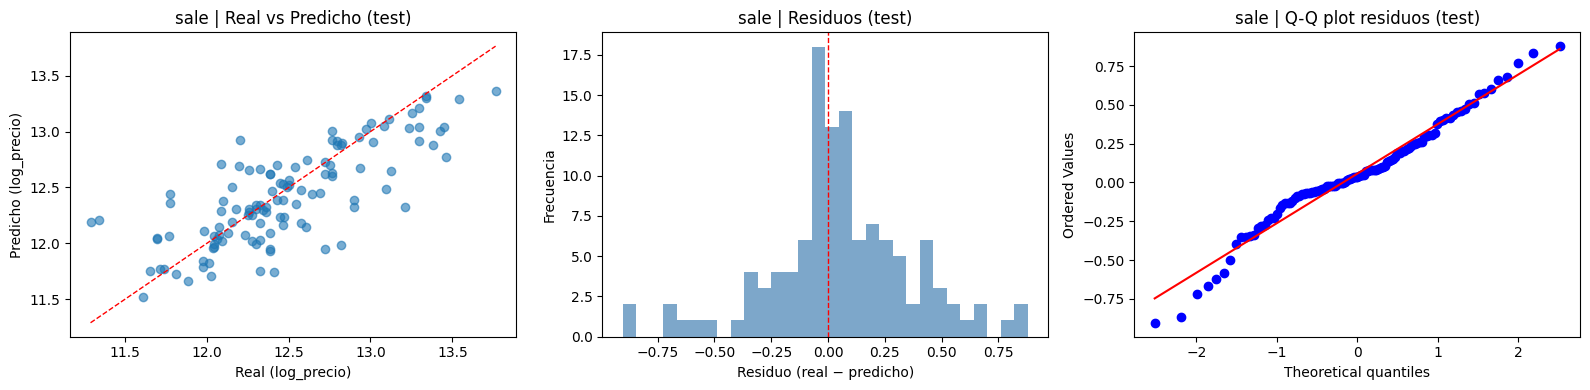


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango válido: [6.1079, 7.8074]
  Outliers eliminados: 26 de 477 (5.5%)
Filas tras limpieza: 451
Features: 49 | Train: 360 | Test: 91

Buscando hiperparámetros (288 combinaciones posibles, CV=5)...

Mejores parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 5, 'subsample': 0.7}

Métricas (train / CV / test):
split     MSE    RMSE     MAE      R2    MAPE
train 0.01987 0.14094 0.10599 0.78102 0.01523
   CV     NaN 0.21549     NaN     NaN     NaN
 test 0.05612 0.23690 0.17041 0.47657 0.02443

Sobreajuste → ratio RMSE test/train: 1.6808 | delta R2 train-test: 0.3045

Top 15 feature importances:
                       feature  importance
  log_superficie_construida_m2     0.15030
              municipio_Laredo     0.11965
            numero_dormitorios     0.10822
                  numero_banos     0.07233
           municipio_Santander

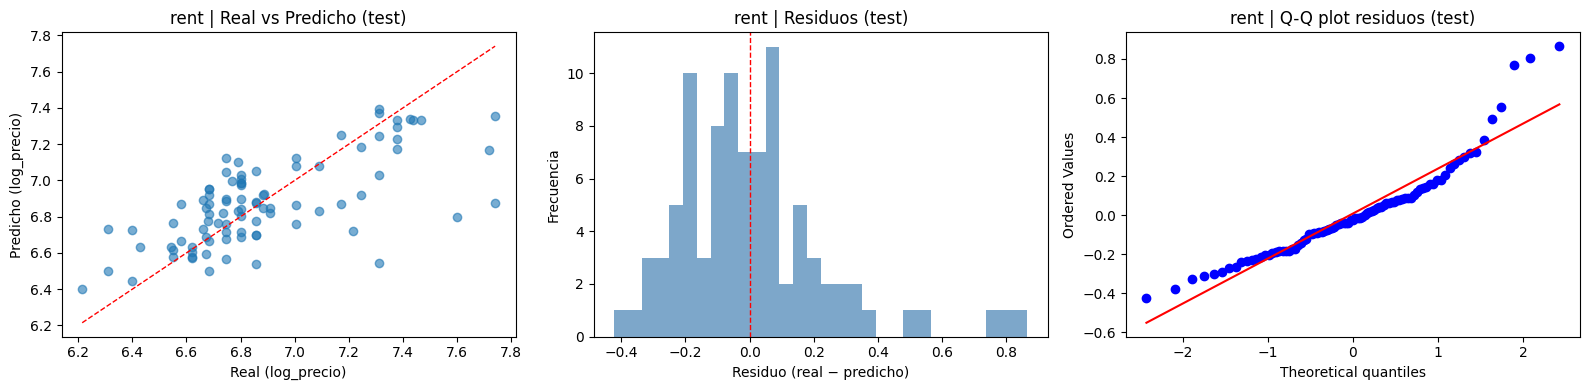


RESUMEN GLOBAL
dataset  n_filas_limpias  n_features  train_RMSE  cv_RMSE  test_RMSE  train_R2  test_R2  ratio_RMSE_test_train  delta_R2_train_test
   sale              582          70      0.0561   0.3036     0.3237    0.9896   0.5781                 5.7692               0.4114
   rent              451          49      0.1409   0.2155     0.2369    0.7810   0.4766                 1.6808               0.3045


,dataset,n_filas_limpias,n_features,train_RMSE,cv_RMSE,test_RMSE,train_R2,test_R2,ratio_RMSE_test_train,delta_R2_train_test
0,sale,582,70,0.056105,0.303622,0.323684,0.989570,0.578139,5.769229,0.411431
1,rent,451,49,0.140944,0.215493,0.236903,0.781021,0.476565,1.680831,0.304456


In [6]:
all_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")

    print("Detectando outliers en el target:")
    df = remove_outliers(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Features y split ─────────────────────────────────────────────────────
    X = prepare_X(df)
    y = df[TARGET_COL].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Features: {X.shape[1]} | Train: {len(X_train)} | Test: {len(X_test)}")

    # ── GridSearchCV ──────────────────────────────────────────────────────────
    xgb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=PARAM_GRID,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    n_combinations = int(np.prod([len(v) for v in PARAM_GRID.values()]))
    print(f"\nBuscando hiperparámetros ({n_combinations} combinaciones posibles, CV=5)...")
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    cv_rmse     = float(-grid_search.best_score_)
    print("\nMejores parámetros:", best_params)

    # ── Reentrenamiento con mejores parámetros ────────────────────────────────
    best_xgb = XGBRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    best_xgb.fit(X_train, y_train)

    pred_train = best_xgb.predict(X_train)
    pred_test  = best_xgb.predict(X_test)

    # ── Métricas ──────────────────────────────────────────────────────────────
    train_metrics = get_metrics(y_train, pred_train)
    test_metrics  = get_metrics(y_test,  pred_test)

    summary_metrics = pd.concat([
        train_metrics.assign(split="train"),
        pd.DataFrame({"MSE": [None], "RMSE": [cv_rmse], "MAE": [None], "R2": [None], "MAPE": [None], "split": ["CV"]}),
        test_metrics.assign(split="test"),
    ], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]

    print("\nMétricas (train / CV / test):")
    print(summary_metrics.round(5).to_string(index=False))

    ratio = float(test_metrics["RMSE"].iloc[0]) / max(float(train_metrics["RMSE"].iloc[0]), 1e-9)
    delta_r2 = float(train_metrics["R2"].iloc[0]) - float(test_metrics["R2"].iloc[0])
    print(f"\nSobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R2 train-test: {delta_r2:.4f}")

    # ── Feature importances ───────────────────────────────────────────────────
    feat_imp = pd.DataFrame({
        "feature":    X_train.columns,
        "importance": best_xgb.feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    print("\nTop 15 feature importances:")
    print(feat_imp.round(5).to_string(index=False))

    # ── Gráficos ──────────────────────────────────────────────────────────────
    residuals = y_test - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.6)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{dataset_name} | Real vs Predicho (test)")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{dataset_name} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{dataset_name} | Q-Q plot residuos (test)")

    plt.tight_layout()
    plt.show()

    # ── Acumulación ───────────────────────────────────────────────────────────
    all_rows.append({
        "dataset":               dataset_name,
        "n_filas_limpias":       len(df),
        "n_features":            X.shape[1],
        "train_RMSE":            float(train_metrics["RMSE"].iloc[0]),
        "cv_RMSE":               cv_rmse,
        "test_RMSE":             float(test_metrics["RMSE"].iloc[0]),
        "train_R2":              float(train_metrics["R2"].iloc[0]),
        "test_R2":               float(test_metrics["R2"].iloc[0]),
        "ratio_RMSE_test_train": ratio,
        "delta_R2_train_test":   delta_r2,
    })

# ── Resumen global ────────────────────────────────────────────────────────────
summary = pd.DataFrame(all_rows)
print()
print("=" * 100)
print("RESUMEN GLOBAL")
print(summary.round(4).to_string(index=False))
summary